In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [26]:
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

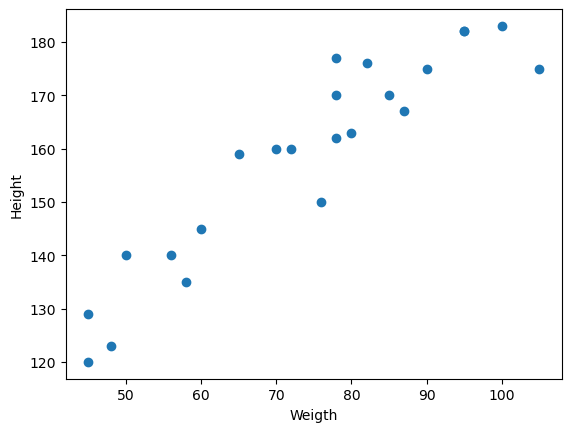

In [27]:
## scatter plt
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weigth")
plt.ylabel("Height")

In [28]:
## corrr
df.corr()


,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


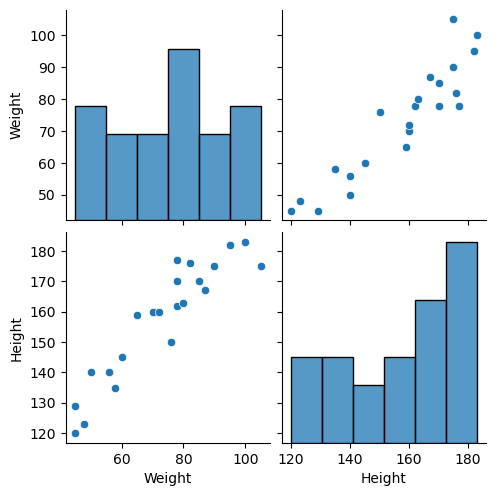

In [29]:
## seaborn 
sns.pairplot(df)

In [30]:
## independent and dependent feature
X = df[['Weight']]
y= df["Height"]


In [31]:
## train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [32]:
## standardization
from sklearn.preprocessing import StandardScaler


In [33]:
scaler = StandardScaler()
X_train  = scaler.fit_transform(X_train)

In [34]:
X_test = scaler.transform(X_test)

In [37]:
## apply Simple  linear regression
from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs=-1)

In [38]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [40]:
print("Coefficiient of slope",regression.coef_)
print("IIntercept",regression.intercept_)

Coefficiient of slope [17.2982057]
IIntercept 156.47058823529412


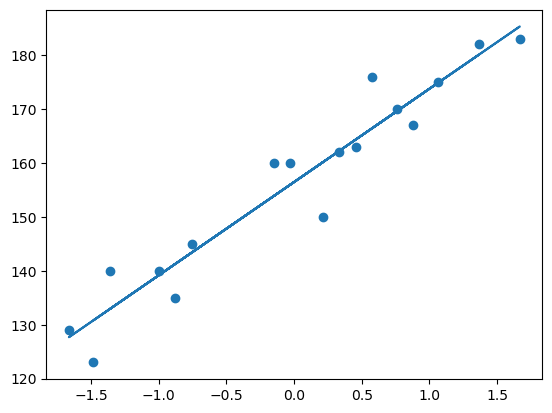

In [42]:
## plt trainng data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [47]:
## prediction for test data
y_pred = regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [50]:
## perfromnace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [51]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [52]:
from sklearn.metrics import r2_score

In [54]:
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [55]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

## OLS Linear Regression

In [56]:
import statsmodels.api as sm

In [57]:
model = sm.OLS(y_train,X_train).fit()

In [58]:
prediction = model.predict(X_test)
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [60]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                       0.664
Time:                        12:27:48   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [63]:
regression.predict(scaler.transform([[72]]))

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])